In [1]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
tau = 10.0  # ms
taus = 2.0  # ms
dt = 0.1    # ms
L = -70.0   # mV
EI = -80.0  # mV
Vth = -50.0 # mV
Vr = -60.0  # mV

N = 20
I = 25.0    # mV
GI = 0.5    # mV

def simulate_ring(T=200.0, G1=1.0, G2=0.2, seed=0):
    steps = int(T / dt)
    t = np.arange(steps + 1) * dt

    # memory potential and conductances for N neurons over time
    V = np.zeros((N, steps + 1))
    gE = np.zeros((N, steps + 1))
    gI = np.zeros((N, steps + 1))

    # set random initial voltages between L and Vr
    rng = np.random.default_rng(seed)
    V[:, 0] = rng.uniform(L, Vr, size=N)

    # a list of N lists to store spike times for all neurons
    spike_times = [[] for _ in range(N)]
    decay = np.exp(-dt / taus)
    all_idx = np.arange(N)

    for n in range(steps):                 

        # decay conductances at time step n
        ge = gE[:, n] * decay
        gi = gI[:, n] * decay

        # exponential Euler update for voltage
        A = L + I + gi * EI
        B = 1.0 + ge + gi
        Vinf = A / B
        Vnew = Vinf + (V[:, n] - Vinf) * np.exp(-B * dt / tau)

        # store decayed values for next time step
        gE[:, n+1] = ge
        gI[:, n+1] = gi
        V[:, n+1] = Vnew

        fired = np.where(Vnew >= Vth)[0]

        if len(fired) > 0:
            for i in fired:
                spike_times[i].append(t[n+1])

            V[fired, n] = 0
            V[fired, n+1] = Vr

            for i in fired:
                # self-excitation
                gE[i, n+1] += G1

                # nearest-neighbor excitation
                gE[(i-1) % N, n+1] += G2
                gE[(i+1) % N, n+1] += G2

                # global inhibition to all others
                others = all_idx[all_idx != i]
                gI[others, n+1] += GI

    return t, V, spike_times

In [ ]:
def classify_phase(spike_times, N=20, transient=10.0, min_spikes=1):
    """
    Returns:
        0 -> mixed / silent 
        1 -> WTA
        2 -> wave
    """
    
    # count spike times after transient time
    counts = np.array([
        np.sum(np.array(st) >= transient) for st in spike_times
    ])
    total_spikes = counts.sum()

    if total_spikes < min_spikes:
        return 0   # neuron is silent or weakly active

    # identify active neurons with at least min_spikes after transient
    active = np.where(counts >= min_spikes)[0]

    if len(active) < N:
        return 1   # WTA: only a subset of neurons are active
    else:
        return 2   # wave: all neurons are active one time or another

In [3]:
#  to identify the wave and winner-take-all phases in the G1 and G2 phase space.

G1_vals = np.linspace(0.0, 2, 16)
G2_vals = np.linspace(0.0, 2, 16)

phase_map = np.zeros((len(G2_vals), len(G1_vals)), dtype=int)

for ix, G1 in enumerate(G1_vals):
    for iy, G2 in enumerate(G2_vals):
        t, V, spike_times = simulate_ring(T=500.0, G1=G1, G2=G2, seed=0)
        phase_map[iy, ix] = classify_phase(spike_times, N=N, transient=100.0)


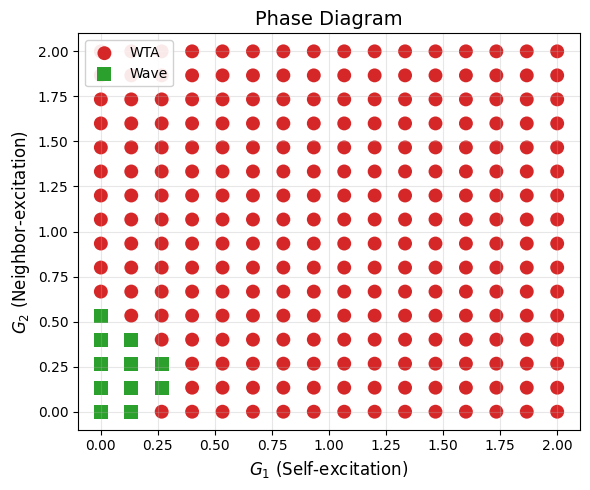

In [4]:
# ------ plotting phase_map for G1 vs G2 ------

G1_grid, G2_grid = np.meshgrid(G1_vals, G2_vals)

# flatten everything for scatter plotting
x = G1_grid.ravel()
y = G2_grid.ravel()
phases = phase_map.ravel()

# masks
mask_wta   = phases == 1
mask_wave  = phases == 2
mask_other = phases == 0

plt.figure(figsize=(6, 5))

# WTA points 
plt.scatter(
    x[mask_wta], y[mask_wta],
    s=100, c='tab:red', marker='o',
    edgecolors='none', label='WTA'
)

# Wave points 
plt.scatter(
    x[mask_wave], y[mask_wave],
    s=100, c='tab:green', marker='s',
    edgecolors='none', label='Wave'
)

# Silent / mixed points
if np.any(mask_other):
    plt.scatter(
        x[mask_other], y[mask_other],
        s=80, c='gray', marker='x',
        linewidths=1.5, alpha=0.6, label='Silent'
    )

plt.xlabel(r'$G_1$ (Self-excitation)', fontsize=12)
plt.ylabel(r'$G_2$ (Neighbor-excitation)', fontsize=12)
plt.title('Phase Diagram', fontsize=14)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.show()

In [5]:
def plot_raster(G1, G2, T=200.0, seed=0):
   
    t, V, spikes = simulate_ring(T=T, G1=G1, G2=G2, seed=seed)

    plt.figure(figsize=(10, 4))
    for i in range(N):
        plt.vlines(spikes[i], i + 0.5, i + 1.5)

    plt.yticks(range(1, N + 1))
    plt.ylabel('Neuron index')
    plt.xlabel('Time (ms)')
    plt.title(fr'Raster plot: $G_1={G1:.2f},\; G_2={G2:.2f}$')
    plt.ylim(0.5, N + 0.5)
    plt.tight_layout()
    plt.show()


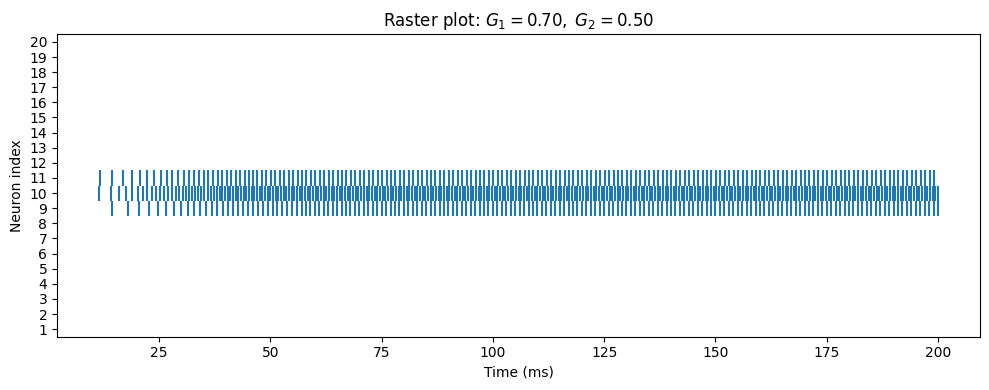

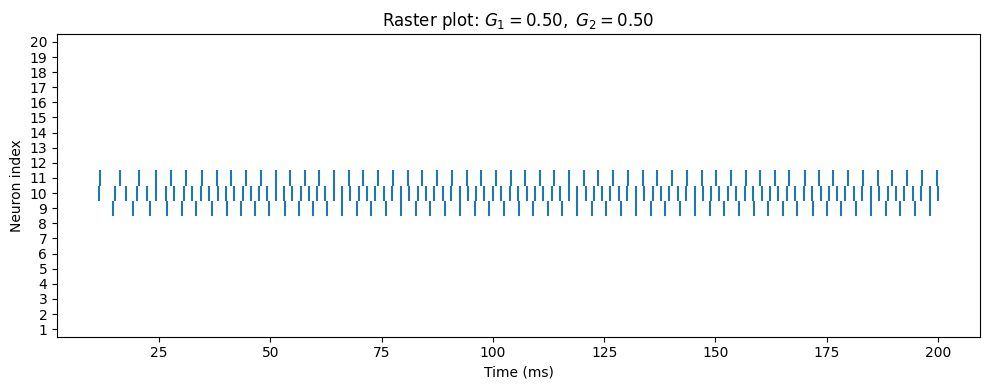

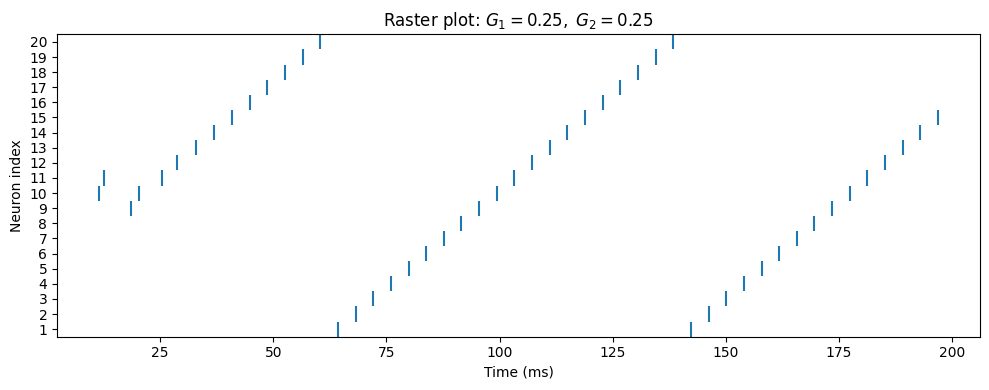

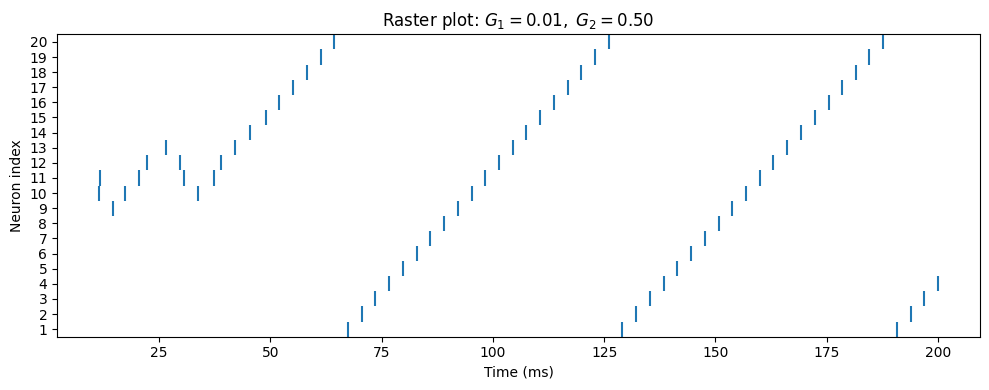

In [18]:
# example: plot WTA dynamics
plot_raster(*(0.7, 0.5), T=200.0, seed=0)
plot_raster(*(0.5, 0.5), T=200.0, seed=0)

# example: plot wave dynamics
plot_raster(*(0.25, 0.25), T=200.0, seed=0)
plot_raster(*(0.01, 0.5), T=200.0, seed=0)
